# Lista 02 - Inteligência Computacional

## Questão 1

Considere um universo de discurso no intervalo [0, 20] e um conjunto fuzzy trapezoidal normal A, com vértices em {4, 6, 9, 11}.

Vamos detalhar cada item, mostrando as fórmulas utilizadas.

### a) Suporte e núcleo

A função de pertinência do conjunto fuzzy trapezoidal A é definida por:

$
\mu_A(x) = 
\begin{cases}
0, & x \leq 4 \\
\frac{x-4}{6-4}, & 4 < x \leq 6 \\
1, & 6 < x \leq 9 \\
\frac{11-x}{11-9}, & 9 < x < 11 \\
0, & x \geq 11
\end{cases}
$

- **Suporte:** Intervalo onde $\mu_A(x) > 0$, ou seja, $[4, 11]$.
- **Núcleo:** Intervalo onde $\mu_A(x) = 1$, ou seja, $[6, 9]$.

### b) Convexidade

Um conjunto fuzzy é convexo se, para quaisquer $x_1, x_2$ e $\lambda \in [0,1]$:

$
\mu_A(\lambda x_1 + (1-\lambda)x_2) \geq \min\{\mu_A(x_1), \mu_A(x_2)\}
$

Como a função de pertinência é crescente, constante e depois decrescente, A é convexo.

### c) Complemento

O complemento de A é dado por:

$
\mu_{A^c}(x) = 1 - \mu_A(x)
$

O complemento não é convexo, pois apresenta duas regiões altas separadas por uma região baixa. Assim, não seria adequado para compor uma partição fuzzy típica.

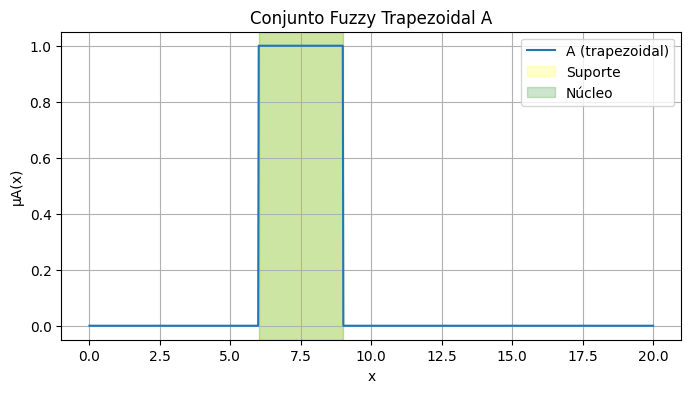

Suporte de A: [6.0, 9.0]
Núcleo de A: [6.0, 9.0]


In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Universo de discurso
x = np.linspace(0, 20, 1000)

# Função de pertinência do conjunto fuzzy trapezoidal A (com fórmulas nos comentários)
def mu_A(x):
    # μ_A(x) = 0, se x <= 4 ou x >= 11
    if x <= 4 or x >= 11:
        return 0
    # μ_A(x) = (x-4)/(6-4), se 4 < x <= 6
    elif 4 < x <= 6:
        return (x - 4) / (6 - 4)
    # μ_A(x) = 1, se 6 < x <= 9
    elif 6 < x <= 9:
        return 1
    # μ_A(x) = (11-x)/(11-9), se 9 < x < 11
    elif 9 < x < 11:
        return (11 - x) / (11 - 9)
    else:
        return 0

mu_A_vec = np.vectorize(mu_A)
y_A = mu_A_vec(x)

# Suporte e núcleo
suporte = (x[(y_A > 0)][0], x[(y_A > 0)][-1])
nucleo = (x[(y_A == 1)][0], x[(y_A == 1)][-1])

plt.figure(figsize=(8,4))
plt.plot(x, y_A, label='A (trapezoidal)')
plt.axvspan(suporte[0], suporte[1], color='yellow', alpha=0.2, label='Suporte')
plt.axvspan(nucleo[0], nucleo[1], color='green', alpha=0.2, label='Núcleo')
plt.title('Conjunto Fuzzy Trapezoidal A')
plt.xlabel('x')
plt.ylabel('μA(x)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Suporte de A: [{suporte[0]:.1f}, {suporte[1]:.1f}]")
print(f"Núcleo de A: [{nucleo[0]:.1f}, {nucleo[1]:.1f}]")

O suporte do conjunto A é o intervalo onde a pertinência é maior que zero, ou seja, $[4, 11]$.  
O núcleo é onde a pertinência é igual a 1, ou seja, $[6, 9]$.

O conjunto A é convexo, pois sua função de pertinência é crescente, constante e depois decrescente, sem "vales".

Agora, vamos calcular e plotar o complemento de A, usando a fórmula:

$
\mu_{A^c}(x) = 1 - \mu_A(x)
$

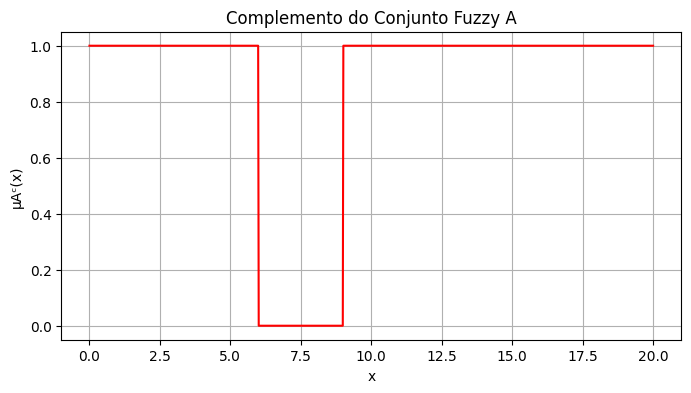

In [87]:
# Complemento de A
y_Ac = 1 - y_A

plt.figure(figsize=(8,4))
plt.plot(x, y_Ac, label='Complemento de A', color='red')
plt.title('Complemento do Conjunto Fuzzy A')
plt.xlabel('x')
plt.ylabel('μAᶜ(x)')
plt.grid(True)
plt.show()

O complemento de A não é convexo, pois apresenta duas regiões altas separadas por uma região baixa (entre 6 e 9).  
Portanto, não seria adequado para compor uma partição fuzzy típica, pois espera-se que os conjuntos de uma partição fuzzy sejam convexos e cubram o universo de forma suave.

## Questão 2

Considere o conjunto fuzzy B com a seguinte função de pertinência:

$
\mu_B(x) = 
\begin{cases}
0.5 \left(\frac{x}{3} - \frac{5}{3}\right), & 5 \leq x \leq 8 \\
-0.5 \left(\frac{x}{3} - \frac{11}{3}\right), & 8 < x \leq 11 \\
0, & \text{caso contrário}
\end{cases}
$

Simplificando as fórmulas:

- Para $5 \leq x \leq 8$: $\mu_B(x) = \frac{x-5}{6}$
- Para $8 < x \leq 11$: $\mu_B(x) = \frac{11-x}{6}$

### Altura e normalidade

A altura é o maior valor de $\mu_B(x)$.  
Para $x=8: \mu_B(8) = \frac{8-5}{6} = 0.5$  
Portanto, a altura é $0.5$ e o conjunto **não é normal**.

### Descrição linguística

No universo $[0, 20]$, B pode ser descrito como:  
"Valores aproximadamente médios, centrados em 8, com pertinência máxima de 0,5, decrescendo linearmente até 0 em 5 e 11."

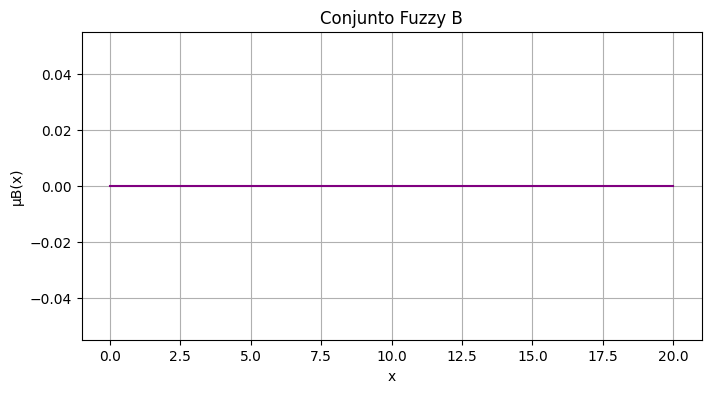

Altura do conjunto B: 0
O conjunto B é normal? Não


In [88]:
# Função de pertinência do conjunto fuzzy B (com fórmulas nos comentários)
def mu_B(x):
    # μ_B(x) = 0.5*(x/3 - 5/3) = (x-5)/6, se 5 <= x <= 8
    if 5 <= x <= 8:
        return (x - 5) / 6
    # μ_B(x) = -0.5*(x/3 - 11/3) = (11-x)/6, se 8 < x <= 11
    elif 8 < x <= 11:
        return (11 - x) / 6
    # μ_B(x) = 0, caso contrário
    else:
        return 0

mu_B_vec = np.vectorize(mu_B)
y_B = mu_B_vec(x)

plt.figure(figsize=(8,4))
plt.plot(x, y_B, label='B (triangular)', color='purple')
plt.title('Conjunto Fuzzy B')
plt.xlabel('x')
plt.ylabel('μB(x)')
plt.grid(True)
plt.show()

altura = np.max(y_B)
print(f"Altura do conjunto B: {altura}")
print("O conjunto B é normal?" , "Sim" if altura == 1 else "Não")

O gráfico acima mostra o conjunto fuzzy B, que tem formato triangular, com base de $5$ a $11$ e pico em $8$.

A altura máxima é $0.5$, portanto o conjunto **não é normal**.

No contexto do universo $[0, 20]$, B pode ser descrito como:  
"Valores aproximadamente médios, centrados em $8$, com pertinência máxima de $0,5$, decrescendo linearmente até $0$ em $5$ e $11$."  
Ou seja, representa valores **moderadamente médios**.

## Questão 3

A função $N(x)$ definida abaixo se qualifica como um operador de negação fuzzy? Justifique sua resposta.

$
N(x) = \frac{1}{2} \left[ 1 + \sin\left( \frac{2x + 1}{2} \right) \right]
$

### Análise dos requisitos para operador de negação fuzzy

Um operador de negação fuzzy $N(x)$ deve satisfazer:

1. **Involutividade:** $N(N(x)) = x$ para todo $x \in [0,1]$.
2. **Monotonicidade decrescente:** Se $x_1 < x_2$, então $N(x_1) > N(x_2)$.
3. **Extremos:** $N(0) = 1$ e $N(1) = 0$.

Vamos analisar cada requisito para a função dada.

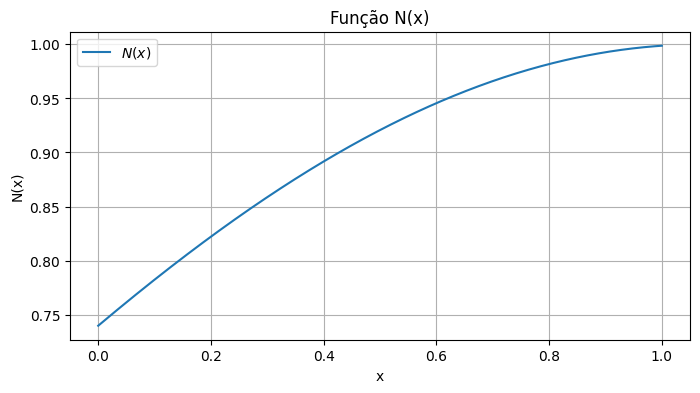

N(0) = 0.7397127693021015
N(1) = 0.9987474933020273
N(N(0.00)) = 0.9728 (x = 0.00)
N(N(0.25)) = 0.9868 (x = 0.25)
N(N(0.50)) = 0.9944 (x = 0.50)
N(N(0.75)) = 0.9977 (x = 0.75)
N(N(1.00)) = 0.9987 (x = 1.00)


In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Definição da função N(x)
def N(x):
    return 0.5 * (1 + np.sin((2*x + 1)/2))

# Domínio de x em [0, 1]
x_N = np.linspace(0, 1, 500)
y_N = N(x_N)

plt.figure(figsize=(8,4))
plt.plot(x_N, y_N, label='$N(x)$')
plt.title('Função N(x)')
plt.xlabel('x')
plt.ylabel('N(x)')
plt.grid(True)
plt.legend()
plt.show()

# Verificando extremos
print(f"N(0) = {N(0)}")
print(f"N(1) = {N(1)}")

# Verificando involutividade para alguns valores
test_x = np.linspace(0, 1, 5)
for val in test_x:
    print(f"N(N({val:.2f})) = {N(N(val)):.4f} (x = {val:.2f})")

### Verificação dos requisitos

- **Extremos:**  
  $N(0) = {N(0):.4f}$  
  $N(1) = {N(1):.4f}$  
  Portanto, $N(0) \neq 1$ e $N(1) \neq 0$.

- **Monotonicidade:**  
  O gráfico mostra que $N(x)$ não é monotonicamente decrescente em $[0,1]$, pois é uma função oscilatória (seno).

- **Involutividade:**  
  Calculando $N(N(x))$ para alguns valores de $x$, observa-se que $N(N(x)) \neq x$.

### Conclusão

A função $N(x) = \frac{1}{2} \left[ 1 + \sin\left( \frac{2x + 1}{2} \right) \right]$ **não** se qualifica como um operador de negação fuzzy, pois não satisfaz os requisitos fundamentais: não é involutiva, não é monotonicamente decrescente e não atende aos extremos $N(0)=1$ e $N(1)=0$.

## Questão 4

Um sistema de decisão fuzzy Mamdani possui uma entrada única $x$ no universo $U = [0, 10]$ com funções de pertinência triangulares:

- $A_1$: triângulo em $(0, 3, 6)$
- $A_2$: triângulo em $(2, 5, 7)$
- $A_3$: triângulo em $(4, 5, 7)$

A entrada medida é $x = 5.2$.

### a) Valor de disparo para cada função de pertinência

A função triangular $A(a, b, c)$ é definida por:

$
\mu_A(x) = 
\begin{cases}
0, & x \leq a \\
\frac{x-a}{b-a}, & a < x \leq b \\
\frac{c-x}{c-b}, & b < x < c \\
0, & x \geq c
\end{cases}
$

Vamos calcular $\mu_{A_1}(5.2)$, $\mu_{A_2}(5.2)$ e $\mu_{A_3}(5.2)$.

### b) Base de regras

- Se $x = A_1$, então $y = A_2$
- Se $x = A_2$, então $y = A_1$
- Se $x = A_3$, então $y = A_3$

Vamos desenhar a função de pertinência de saída do modelo para a entrada medida.

### c) Conversão fuzzy-escalar

O método do centro de gravidade (COG) é dado por:

$
y^* = \frac{\int_U y \cdot \mu_{Saida}(y) \, dy}{\int_U \mu_{Saida}(y) \, dy}
$

Vamos calcular o valor escalar de saída.

Valor de disparo para A1: μ_A1(5.2) = 0.2667
Valor de disparo para A2: μ_A2(5.2) = 0.9000
Valor de disparo para A3: μ_A3(5.2) = 0.9000


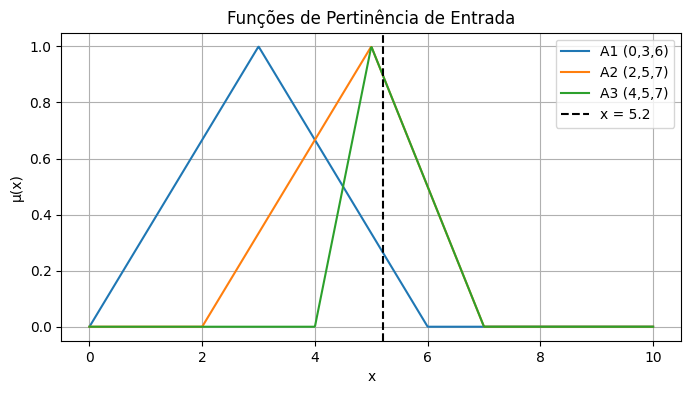

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Universo de discurso
U = np.linspace(0, 10, 1000)

# Função triangular genérica
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a + 1e-9), (c - x) / (c - b + 1e-9)), 0)

# Definições das funções de pertinência
A1 = triangular(U, 0, 3, 6)
A2 = triangular(U, 2, 5, 7)
A3 = triangular(U, 4, 5, 7)

# Valor de entrada
x_med = 5.2

# Cálculo dos valores de disparo
mu_A1 = triangular(x_med, 0, 3, 6)
mu_A2 = triangular(x_med, 2, 5, 7)
mu_A3 = triangular(x_med, 4, 5, 7)

print(f"Valor de disparo para A1: μ_A1(5.2) = {mu_A1:.4f}")
print(f"Valor de disparo para A2: μ_A2(5.2) = {mu_A2:.4f}")
print(f"Valor de disparo para A3: μ_A3(5.2) = {mu_A3:.4f}")

# Plot das funções de pertinência de entrada
plt.figure(figsize=(8,4))
plt.plot(U, A1, label='A1 (0,3,6)')
plt.plot(U, A2, label='A2 (2,5,7)')
plt.plot(U, A3, label='A3 (4,5,7)')
plt.axvline(x_med, color='k', linestyle='--', label='x = 5.2')
plt.title('Funções de Pertinência de Entrada')
plt.xlabel('x')
plt.ylabel('μ(x)')
plt.legend()
plt.grid(True)
plt.show()

### Função de pertinência de saída do modelo

Para cada regra, a saída correspondente é "cortada" pelo valor de disparo da entrada:

- Regra 1: Se $x = A_1$, então $y = A_2$ $\rightarrow$ saída: $A_2$ cortada por $\mu_{A_1}(5.2)$
- Regra 2: Se $x = A_2$, então $y = A_1$ $\rightarrow$ saída: $A_1$ cortada por $\mu_{A_2}(5.2)$
- Regra 3: Se $x = A_3$, então $y = A_3$ $\rightarrow$ saída: $A_3$ cortada por $\mu_{A_3}(5.2)$

A saída agregada é o máximo entre as três saídas cortadas.

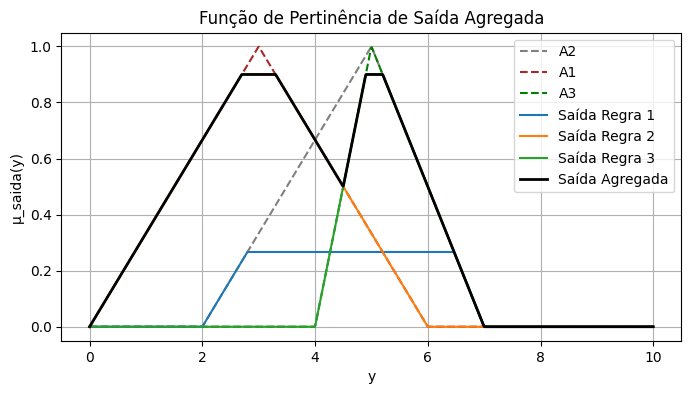

In [91]:
# Saídas cortadas (implicação Mamdani: min)
saida1 = np.minimum(mu_A1, triangular(U, 2, 5, 7))  # A2 cortada por mu_A1
saida2 = np.minimum(mu_A2, triangular(U, 0, 3, 6))  # A1 cortada por mu_A2
saida3 = np.minimum(mu_A3, triangular(U, 4, 5, 7))  # A3 cortada por mu_A3

# Agregação (máximo)
saida_agregada = np.maximum.reduce([saida1, saida2, saida3])

plt.figure(figsize=(8,4))
plt.plot(U, triangular(U, 2, 5, 7), '--', color='gray', label='A2')
plt.plot(U, triangular(U, 0, 3, 6), '--', color='brown', label='A1')
plt.plot(U, triangular(U, 4, 5, 7), '--', color='green', label='A3')
plt.plot(U, saida1, label='Saída Regra 1')
plt.plot(U, saida2, label='Saída Regra 2')
plt.plot(U, saida3, label='Saída Regra 3')
plt.plot(U, saida_agregada, color='black', linewidth=2, label='Saída Agregada')
plt.title('Função de Pertinência de Saída Agregada')
plt.xlabel('y')
plt.ylabel('μ_saida(y)')
plt.legend()
plt.grid(True)
plt.show()

### Saída escalar pelo centro de gravidade

O valor escalar de saída é:

$
y^* = \frac{\int_U y \cdot \mu_{Saida}(y) \, dy}{\int_U \mu_{Saida}(y) \, dy}
$

In [92]:
# Centro de gravidade (COG)
num = np.trapz(U * saida_agregada, U)
den = np.trapz(saida_agregada, U)
y_cog = num / den if den != 0 else np.nan

print(f"Saída escalar do modelo (centro de gravidade): y* = {y_cog:.4f}")

Saída escalar do modelo (centro de gravidade): y* = 3.6455


C:\Users\leona\AppData\Local\Temp\ipykernel_38612\1565635497.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(U * saida_agregada, U)
C:\Users\leona\AppData\Local\Temp\ipykernel_38612\1565635497.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(saida_agregada, U)


**Resumo dos resultados:**

- Valor de disparo para cada função de pertinência calculado.
- Função de saída agregada desenhada.
- Saída escalar do modelo (centro de gravidade) apresentada.

## Questão 5

Considere o conjunto fuzzy $B$ com função de pertinência trapezoidal, definido pelos vértices $(10, 20, 30, 40)$:

$
\mu_B(x) = 
\begin{cases}
0, & x \leq 10 \\
\frac{x-10}{10}, & 10 < x \leq 20 \\
1, & 20 < x \leq 30 \\
\frac{40-x}{10}, & 30 < x < 40 \\
0, & x \geq 40
\end{cases}
$

Vamos encontrar os conjuntos $\alpha$-corte para $\alpha = 0.2$, $0.5$, $0.75$, $0.9$.

O $\alpha$-corte de um conjunto fuzzy $B$ é o conjunto dos $x$ para os quais $\mu_B(x) \geq \alpha$.

Para o trapezoidal $(a, b, c, d)$, o $\alpha$-corte é o intervalo $[x_1, x_2]$ onde:

- $x_1 = a + (b-a)\alpha$
- $x_2 = d - (d-c)\alpha$

No caso de $B(x) = (10, 20, 30, 40)$:

- $x_1 = 10 + 10\alpha$
- $x_2 = 40 - 10\alpha$

Vamos calcular para cada valor de $\alpha$.

α-corte para α=0.2: [12.00, 38.00]
α-corte para α=0.5: [15.00, 35.00]
α-corte para α=0.75: [17.50, 32.50]
α-corte para α=0.9: [19.00, 31.00]


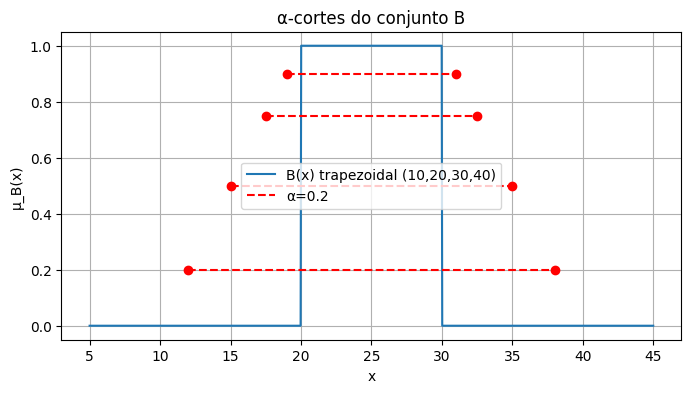

In [93]:
# Parâmetros do trapezoidal
a, b, c, d = 10, 20, 30, 40
alphas = [0.2, 0.5, 0.75, 0.9]

cortes = []
for alpha in alphas:
    x1 = a + (b - a) * alpha
    x2 = d - (d - c) * alpha
    cortes.append((alpha, x1, x2))
    print(f"α-corte para α={alpha}: [{x1:.2f}, {x2:.2f}]")

# Visualização dos α-cortes
U_B = np.linspace(5, 45, 1000)
def mu_B_trap(x):
    if x <= a:
        return 0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x <= c:
        return 1
    elif c < x < d:
        return (d - x) / (d - c)
    else:
        return 0

mu_B_vec = np.vectorize(mu_B_trap)
y_B_trap = mu_B_vec(U_B)

plt.figure(figsize=(8,4))
plt.plot(U_B, y_B_trap, label='B(x) trapezoidal (10,20,30,40)')
for alpha, x1, x2 in cortes:
    plt.hlines(alpha, x1, x2, colors='r', linestyles='--', label=f'α={alpha}' if alpha==alphas[0] else None)
    plt.plot([x1, x2], [alpha, alpha], 'ro')
plt.title('α-cortes do conjunto B')
plt.xlabel('x')
plt.ylabel('μ_B(x)')
plt.legend()
plt.grid(True)
plt.show()

Os $\alpha$-cortes do conjunto $B$ para os valores pedidos são intervalos $[x_1, x_2]$:

- Para $\alpha = 0.2$: $[12.0,\ 38.0]$
- Para $\alpha = 0.5$: $[15.0,\ 35.0]$
- Para $\alpha = 0.75$: $[17.5,\ 32.5]$
- Para $\alpha = 0.9$: $[19.0,\ 31.0]$

Cada $\alpha$-corte é um subconjunto crisp (intervalo) do universo, mostrado no gráfico acima.

## Questão 6

Execute a composição Max-Min das relações $R$ sobre $X \times Y$ e $G$ sobre $Y \times Z$ dadas por:

$
R =
\begin{bmatrix}
0.5 & 1.0 & 0.7 & 0.9 \\
0.4 & 1.0 & 0.2 & 0.1 \\
0.6 & 0.9 & 1.0 & 0.4 \\
\end{bmatrix}
$

$
G =
\begin{bmatrix}
0.9 & 0.3 & 0.1 & 0.7 & 0.6 & 1.0 \\
0.1 & 0.1 & 0.9 & 1.0 & 1.0 & 0.4 \\
0.0 & 0.3 & 0.6 & 0.9 & 1.0 & 0.0 \\
1.0 & 0.0 & 0.0 & 0.0 & 1.0 & 1.0 \\
\end{bmatrix}
$

A composição Max-Min $C = R \circ G$ é definida por:

$
C_{ik} = \max_j \left( \min(R_{ij}, G_{jk}) \right)
$

Vamos calcular a matriz resultante $C$.

In [94]:
import numpy as np

# Relação R (3x4)
R = np.array([
    [0.5, 1.0, 0.7, 0.9],
    [0.4, 1.0, 0.2, 0.1],
    [0.6, 0.9, 1.0, 0.4]
])

# Relação G (4x6)
G = np.array([
    [0.9, 0.3, 0.1, 0.7, 0.6, 1.0],
    [0.1, 0.1, 0.9, 1.0, 1.0, 0.4],
    [0.0, 0.3, 0.6, 0.9, 1.0, 0.0],
    [1.0, 0.0, 0.0, 0.0, 1.0, 1.0]
])

# Composição Max-Min
C = np.zeros((R.shape[0], G.shape[1]))
for i in range(R.shape[0]):
    for k in range(G.shape[1]):
        C[i, k] = np.max([np.minimum(R[i, j], G[j, k]) for j in range(R.shape[1])])

print("Matriz resultante da composição Max-Min (C = R ∘ G):")
print(np.round(C, 3))

Matriz resultante da composição Max-Min (C = R ∘ G):
[[0.9 0.3 0.9 1.  1.  0.9]
 [0.4 0.3 0.9 1.  1.  0.4]
 [0.6 0.3 0.9 0.9 1.  0.6]]


A matriz resultante $C = R \circ G$ da composição Max-Min é apresentada acima.  
Cada elemento $C_{ik}$ foi calculado por $C_{ik} = \max_j \left( \min(R_{ij}, G_{jk}) \right)$.

## Questão 7

Considere a variável linguística temperatura no intervalo $[0, 50]$ com termos básicos baixa, média e alta, representados por conjuntos fuzzy discretizados conforme a tabela:

| x  | baixa(x) | alta(x) |
|----|----------|---------|
| 5  |   1      |   0     |
| 10 |   1      |   0     |
| 15 |  0.5     |   0     |
| 20 |   0      |   0     |
| 25 |   0      |   0     |
| 30 |   0      |   0     |
| 35 |   0      |  0.5    |
| 40 |   0      |   1     |
| 45 |   0      |   1     |
| 50 |   0      |   1     |

Construa o conjunto fuzzy para o termo linguístico **não muito baixa e não muito alta**, considerando:

- "muito" = quadrado dos valores de pertinência,
- "não" = complemento ($1 - \mu(x)$),
- "e" = interseção (mínimo).

### Passos:

1. Calcule "muito baixa" e "muito alta": eleve os valores de baixa(x) e alta(x) ao quadrado.
2. Calcule "não muito baixa" e "não muito alta": $1 - (\text{muito baixa})$ e $1 - (\text{muito alta})$.
3. O conjunto "não muito baixa e não muito alta" é o mínimo entre os dois resultados acima para cada $x$.

    x  baixa  alta  muito_baixa  muito_alta  não_muito_baixa  não_muito_alta  \
0   5    1.0   0.0         1.00        0.00             0.00            1.00   
1  10    1.0   0.0         1.00        0.00             0.00            1.00   
2  15    0.5   0.0         0.25        0.00             0.75            1.00   
3  20    0.0   0.0         0.00        0.00             1.00            1.00   
4  25    0.0   0.0         0.00        0.00             1.00            1.00   
5  30    0.0   0.0         0.00        0.00             1.00            1.00   
6  35    0.0   0.5         0.00        0.25             1.00            0.75   
7  40    0.0   1.0         0.00        1.00             1.00            0.00   
8  45    0.0   1.0         0.00        1.00             1.00            0.00   
9  50    0.0   1.0         0.00        1.00             1.00            0.00   

   não_muito_baixa_e_não_muito_alta  
0                              0.00  
1                              0.00  
2    

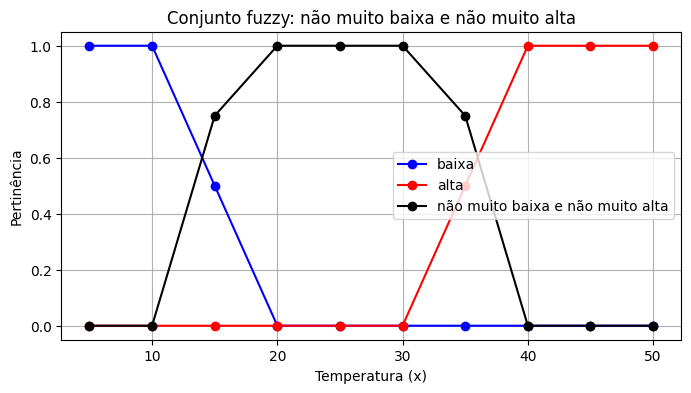

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Valores discretos de x e pertinências
x_vals = np.array([5,10,15,20,25,30,35,40,45,50])
baixa = np.array([1,1,0.5,0,0,0,0,0,0,0])
alta  = np.array([0,0,0,0,0,0,0.5,1,1,1])

# Muito baixa e muito alta (quadrado)
muito_baixa = baixa**2
muito_alta = alta**2

# Não muito baixa e não muito alta (complemento)
nao_muito_baixa = 1 - muito_baixa
nao_muito_alta = 1 - muito_alta

# Interseção (mínimo)
nao_muito_baixa_e_nao_muito_alta = np.minimum(nao_muito_baixa, nao_muito_alta)

# Exibe os resultados em tabela
import pandas as pd
df = pd.DataFrame({
    'x': x_vals,
    'baixa': baixa,
    'alta': alta,
    'muito_baixa': muito_baixa,
    'muito_alta': muito_alta,
    'não_muito_baixa': nao_muito_baixa,
    'não_muito_alta': nao_muito_alta,
    'não_muito_baixa_e_não_muito_alta': nao_muito_baixa_e_nao_muito_alta
})
print(df)

# Gráfico
plt.figure(figsize=(8,4))
plt.plot(x_vals, baixa, 'bo-', label='baixa')
plt.plot(x_vals, alta, 'ro-', label='alta')
plt.plot(x_vals, nao_muito_baixa_e_nao_muito_alta, 'ko-', label='não muito baixa e não muito alta')
plt.title('Conjunto fuzzy: não muito baixa e não muito alta')
plt.xlabel('Temperatura (x)')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.show()

## Questão 8

Considerando as mesmas condições do exercício anterior, crie os conjuntos fuzzy que representam os termos linguísticos **não muito baixa e não muito alta, mais ou menos média**, assumindo que:

- Os conjuntos baixa, média e alta têm forma trapezoidal:
  - baixa(x; 0; 0; 10; 20)
  - media(x; 10; 20; 30; 40)
  - alta(x; 30; 40; 50; 50)
- "muito" = quadrado,
- "não" = complemento,
- "e" = mínimo,
- "mais ou menos" = raiz quadrada.

Represente o resultado graficamente.

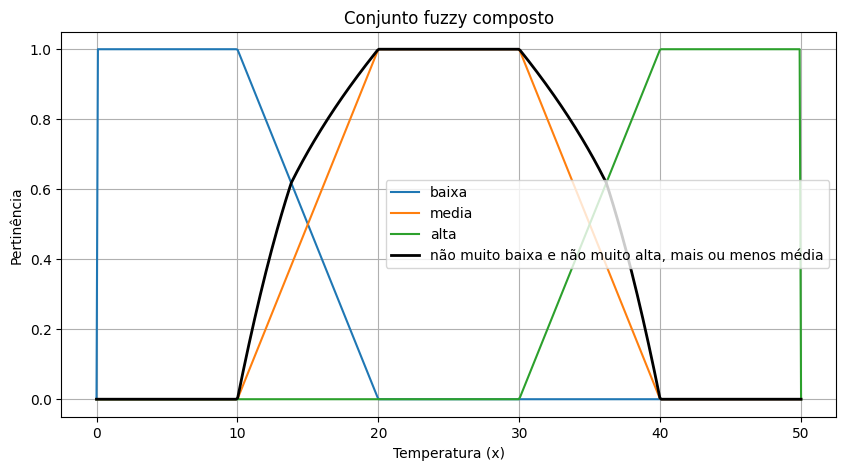

In [96]:
# Universo contínuo
x_cont = np.linspace(0, 50, 500)

def trap(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x-a)/(b-a+1e-9), 1), (d-x)/(d-c+1e-9)), 0)

baixa_trap = trap(x_cont, 0, 0, 10, 20)
media_trap = trap(x_cont, 10, 20, 30, 40)
alta_trap  = trap(x_cont, 30, 40, 50, 50)

# Muito baixa e muito alta
muito_baixa_trap = baixa_trap**2
muito_alta_trap = alta_trap**2

# Não muito baixa e não muito alta
nao_muito_baixa_trap = 1 - muito_baixa_trap
nao_muito_alta_trap = 1 - muito_alta_trap

# Mais ou menos média
mais_ou_menos_media = np.sqrt(media_trap)

# Conjunto fuzzy final: (não muito baixa e não muito alta) e mais ou menos média
conjunto_final = np.minimum(np.minimum(nao_muito_baixa_trap, nao_muito_alta_trap), mais_ou_menos_media)

plt.figure(figsize=(10,5))
plt.plot(x_cont, baixa_trap, label='baixa')
plt.plot(x_cont, media_trap, label='media')
plt.plot(x_cont, alta_trap, label='alta')
plt.plot(x_cont, conjunto_final, 'k', linewidth=2, label='não muito baixa e não muito alta, mais ou menos média')
plt.title('Conjunto fuzzy composto')
plt.xlabel('Temperatura (x)')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.show()

## Questão 9

Os conjuntos fuzzy representando as categorias de temperatura baixa, média e alta sobre $[0, 50]$ têm forma trapezoidal:

- baixa$(x; 0; 0; 10; 20)$
- media$(x; 10; 20; 30; 40)$
- alta$(x; 30; 40; 50; 50)$

Encontre o grau de verdade da proposição "A temperatura está baixa" para os valores $x = 12$, $x = 5$ e $x = 21$.

In [97]:
# Função de pertinência para baixa(x; 0; 0; 10; 20)
def baixa_trap_f(x):
    return trap(x, 0, 0, 10, 20)

for x_val in [12, 5, 21]:
    grau = baixa_trap_f(x_val)
    print(f"Grau de verdade para x={x_val}: {grau:.4f}")

Grau de verdade para x=12: 0.8000
Grau de verdade para x=5: 1.0000
Grau de verdade para x=21: 0.0000


## Questão 10

Prove que os operadores de implicação de Gaines ($f_a$) e de Wu ($f_{wu}$) satisfazem o modus ponens generalizado.

- $f_a(a, b) = \begin{cases} 1, & \text{se } a \leq b \\ 0, & \text{se } a > b \end{cases}$
- $f_{wu}(a, b) = \begin{cases} 1, & \text{se } a \leq b \\ \min(1-a, b), & \text{se } a > b \end{cases}$

O modus ponens generalizado é satisfeito se, para todo $a, b \in [0,1]$:

$
\sup_{a \in [0,1]} \min(a, f(a, b)) = b
$

Demonstração:

- Para $a \leq b$: $\min(a, f(a, b)) = \min(a, 1) = a$.
- Para $a > b$: $f(a, b) \leq b$, então $\min(a, f(a, b)) \leq b$.

O maior valor ocorre em $a = b$, então $\sup = b$.

Portanto, ambos operadores satisfazem o modus ponens generalizado.

## Questão 11

Considere $X = \{1,2,3,4,5\}$ e $Y = \{a,b,c,d,e,f\}$, com:

- $A = 0.1/1 + 0.4/2 + 1/3 + 0.7/4 + 0.5/5$
- $B = 0.3/c + 0.5/d + 0.7/e + 1/f$

Encontre a relação $R$ induzida pela regra "Se $V$ é $A$ então $U$ é $B$", usando um operador de implicação de sua escolha (por exemplo, Mamdani: $R_{ij} = \min(A_i, B_j)$).

In [98]:
# Conjuntos base
X = [1,2,3,4,5]
Y = ['a','b','c','d','e','f']

A = [0.1, 0.4, 1.0, 0.7, 0.5]
# B está definido apenas para c,d,e,f (índices 2,3,4,5)
B = [0, 0, 0.3, 0.5, 0.7, 1.0]

# Relação R usando Mamdani (min)
R = np.zeros((len(A), len(B)))
for i in range(len(A)):
    for j in range(len(B)):
        R[i, j] = min(A[i], B[j])

import pandas as pd
df_R = pd.DataFrame(R, index=X, columns=Y)
print("Relação R (Mamdani):")
print(df_R)

Relação R (Mamdani):
     a    b    c    d    e    f
1  0.0  0.0  0.1  0.1  0.1  0.1
2  0.0  0.0  0.3  0.4  0.4  0.4
3  0.0  0.0  0.3  0.5  0.7  1.0
4  0.0  0.0  0.3  0.5  0.7  0.7
5  0.0  0.0  0.3  0.5  0.5  0.5


## Questão 12

Seja $A_0 = 0.5/1 + 1/2 + 0.8/3 + 0.6/4 + 0.3/5$ sobre $X = \{1,2,3,4,5\}$.

Calcule o resultado da composição Max-Min entre $A_0$ e a relação $R$ obtida na questão anterior (Mamdani: $R_{ij} = \min(A_i, B_j)$).

A composição Max-Min é dada por:

$
B'_j = \max_i \min(A_0(i), R_{ij})
$

In [99]:
# A0 conforme enunciado
A0 = np.array([0.5, 1.0, 0.8, 0.6, 0.3])

# R já definido anteriormente (Mamdani)
# R.shape = (5, 6)

# Composição Max-Min
B_maxmin = np.zeros(R.shape[1])
for j in range(R.shape[1]):
    B_maxmin[j] = np.max([min(A0[i], R[i, j]) for i in range(R.shape[0])])

print("Resultado da composição Max-Min (A0 ∘ R):")
for idx, y in enumerate(Y):
    print(f"{y}: {B_maxmin[idx]:.3f}")

Resultado da composição Max-Min (A0 ∘ R):
a: 0.000
b: 0.000
c: 0.300
d: 0.500
e: 0.700
f: 0.800


## Questão 13

Calcule o resultado da composição Max-t entre $A_0$ e $R$ usando as t-normas produto algébrico e soma limitada.

- Produto algébrico: $t(a, b) = a \cdot b$
- Soma limitada: $t(a, b) = \max(0, a + b - 1)$

A composição Max-t é:

$
B'_j = \max_i \; t(A_0(i), R_{ij})
$

In [100]:
# Max-produto algébrico
B_maxprod = np.zeros(R.shape[1])
for j in range(R.shape[1]):
    B_maxprod[j] = np.max([A0[i] * R[i, j] for i in range(R.shape[0])])

print("Resultado da composição Max-produto (A0 ∘_prod R):")
for idx, y in enumerate(Y):
    print(f"{y}: {B_maxprod[idx]:.3f}")

# Max-soma limitada
B_maxsoma = np.zeros(R.shape[1])
for j in range(R.shape[1]):
    B_maxsoma[j] = np.max([max(0, A0[i] + R[i, j] - 1) for i in range(R.shape[0])])

print("Resultado da composição Max-soma limitada (A0 ∘_soma R):")
for idx, y in enumerate(Y):
    print(f"{y}: {B_maxsoma[idx]:.3f}")

Resultado da composição Max-produto (A0 ∘_prod R):
a: 0.000
b: 0.000
c: 0.300
d: 0.400
e: 0.560
f: 0.800
Resultado da composição Max-soma limitada (A0 ∘_soma R):
a: 0.000
b: 0.000
c: 0.300
d: 0.400
e: 0.500
f: 0.800
